正在加载模型...


Using cache found in /home/ljc/.cache/torch/hub/facebookresearch_dino_main


Downloading: "https://dl.fbaipublicfiles.com/dino/dino_vitbase8_pretrain/dino_vitbase8_pretrain.pth" to /home/ljc/.cache/torch/hub/checkpoints/dino_vitbase8_pretrain.pth


100%|██████████| 327M/327M [00:59<00:00, 5.81MB/s] 


正在处理图像...


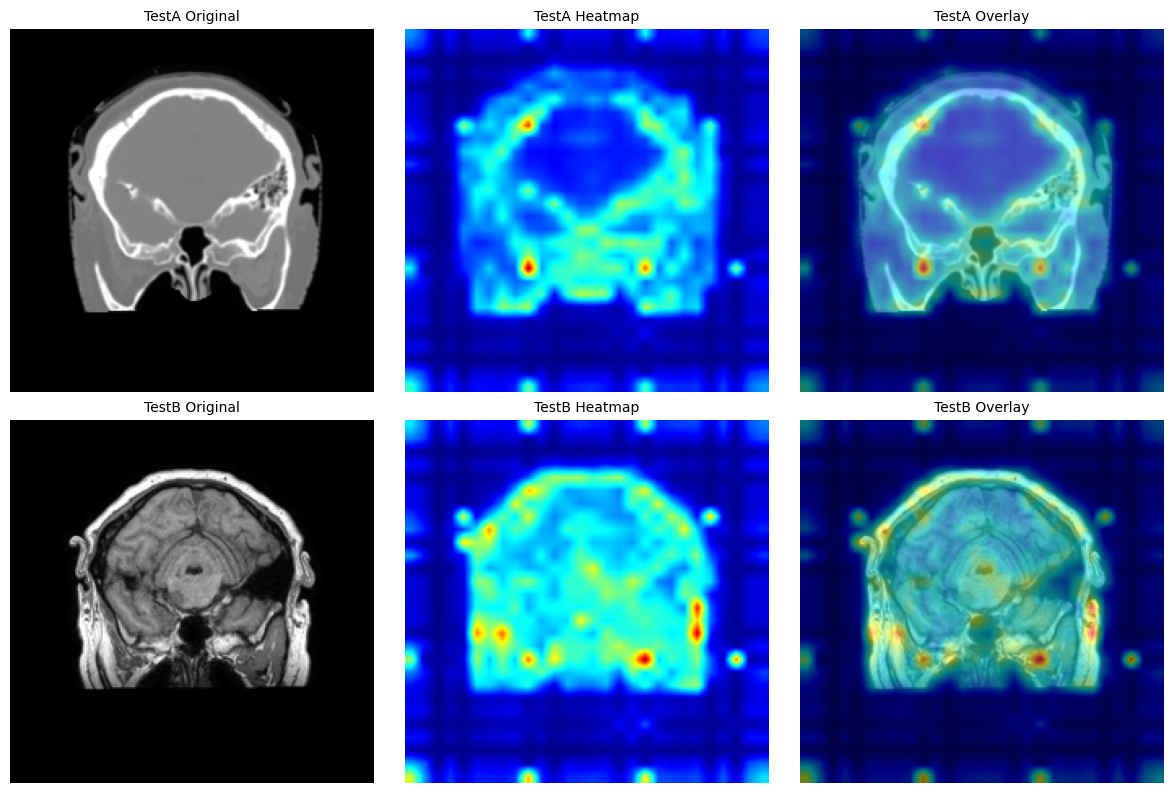

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
from torchvision.models import ViT_B_16_Weights, vit_b_16
import math
from pathlib import Path

# --- 核心计算类 ---

# class AttentionRollout:
#     def __init__(self, model):
#         self.model = model
#         self.attentions = []
#         self._patch_attention_forward()

#     def _patch_attention_forward(self):
#         for block in self.model.encoder.layers:
#             attn = block.self_attention
#             original_forward = attn.forward

#             def forward_wrapper(query, key, value, _orig=original_forward, **kwargs):
#                 kwargs["need_weights"] = True
#                 kwargs["average_attn_weights"] = False
#                 out, weights = _orig(query, key, value, **kwargs)
#                 self.attentions.append(weights.detach().cpu())
#                 return out, weights

#             attn.forward = forward_wrapper

#     def __call__(self, input_tensor):
#         self.attentions = []
#         with torch.no_grad():
#             self.model(input_tensor)
#         return self.compute_rollout()

#     def compute_rollout(self):
#         seq_len = self.attentions[0].size(-1)
#         result = torch.eye(seq_len)
#         for attention in self.attentions:
#             attention = attention[0].mean(dim=0)
#             attention = (attention + torch.eye(seq_len)) / 2.0
#             attention = attention / attention.sum(dim=-1, keepdim=True)
#             result = attention @ result
#         return result[0, 1:]

class AttentionRollout:
    def __init__(self, model):
        self.model = model
        self.attentions = []
        self._register_hooks()

    def _register_hooks(self):
        """
        利用 PyTorch Hook 机制非侵入式地提取 Attention 矩阵。
        DINO 模型的 Transformer blocks 存储在 `model.blocks` 中。
        """
        for block in self.model.blocks:
            # DINO 的注意力模块命名为 'attn'
            block.attn.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        """
        在 block.attn 执行完 forward 后触发。
        DINO 的 Attention forward 返回值为 (x, attn_weights)。
        """
        if isinstance(output, tuple) and len(output) == 2:
            # output[1] 即为形状为 (B, num_heads, N, N) 的注意力权重
            self.attentions.append(output[1].detach().cpu())
        else:
            raise RuntimeError("Hook 捕获的输出格式不匹配，请确保加载的是 DINO 官方权重。")

    def __call__(self, input_tensor):
        self.attentions = [] # 每次调用前清空缓存
        with torch.no_grad():
            self.model(input_tensor)
        return self.compute_rollout()

    def compute_rollout(self):
        if not self.attentions:
            raise RuntimeError("没有捕获到注意力权重。")
            
        seq_len = self.attentions[0].size(-1)
        result = torch.eye(seq_len)
        
        for attention in self.attentions:
            # 聚合多头注意力 (mean over heads)
            attention = attention[0].mean(dim=0)
            # 添加残差连接 (Identity matrix) 避免深层网络权重消失
            attention = (attention + torch.eye(seq_len)) / 2.0
            # 归一化，保证概率总和为 1
            attention = attention / attention.sum(dim=-1, keepdim=True)
            # 矩阵连乘计算 Rollout (信息沿深度的传递)
            result = attention @ result
            
        # 取出 CLS token [0] 对其他所有 Patch tokens [1:] 的注意力分布
        return result[0, 1:]


# --- 工具函数 ---

def get_attention_mask(image_path, model, rollout, image_size=224):
    """处理单张图片并返回其 原始图、热力图、叠加图"""
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)
    device = next(model.parameters()).device  # 获取模型当前所在设备
    input_tensor = transform(img).unsqueeze(0).to(device)
    attention_scores = rollout(input_tensor)

    # 维度计算
    grid_size = int(math.sqrt(attention_scores.numel()))
    mask = attention_scores.reshape(grid_size, grid_size).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    mask = cv2.resize(mask, (image_size, image_size))

    # 生成可视化图
    img_resized = np.array(img.resize((image_size, image_size)))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    overlay = np.float32(heatmap_rgb) / 255.0 * 0.5 + np.float32(img_resized) / 255.0 * 0.5
    
    return img_resized, heatmap_rgb, overlay

def plot_2_rows_grid(image_groups, titles):
    """
    强制两行显示：第一行展示一组，第二行展示一组
    image_groups: [[img1, img2, img3], [img4, img5, img6]]
    """
    rows = 2
    cols = len(image_groups[0])
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 8))
    
    for r in range(rows):
        for c in range(cols):
            axes[r, c].imshow(image_groups[r][c])
            axes[r, c].set_title(titles[r][c], fontsize=10)
            axes[r, c].axis('off')
            
    plt.tight_layout()
    plt.show()

# --- Notebook 运行主逻辑 ---

# 1. 配置参数 (在此修改路径)
IMG_PATH_A = "/home/ljc/code/PaBoT-main/datasets/testA/1BA278_slice092.png" 
IMG_PATH_B = "/home/ljc/code/PaBoT-main/datasets/testB/1BA278_slice092.png"
IMG_SIZE = 224

# 2. 初始化模型
print("正在加载模型...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).to(device).eval()
# 加载 DINO 自监督训练的 ViT-B/16
model = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8').to(device).eval()
rollout = AttentionRollout(model)

# 3. 计算数据
print("正在处理图像...")
a_orig, a_heat, a_over = get_attention_mask(IMG_PATH_A, model, rollout, IMG_SIZE)
b_orig, b_heat, b_over = get_attention_mask(IMG_PATH_B, model, rollout, IMG_SIZE)

# 4. 强制 2 行打印并标注
image_data = [
    [a_orig, a_heat, a_over], # 第一行
    [b_orig, b_heat, b_over]  # 第二行
]

label_data = [
    ["TestA Original", "TestA Heatmap", "TestA Overlay"],
    ["TestB Original", "TestB Heatmap", "TestB Overlay"]
]

plot_2_rows_grid(image_data, label_data)

正在加载 DINO 模型 (Patch Size 8)...


Using cache found in /home/ljc/.cache/torch/hub/facebookresearch_dino_main


正在提取并计算图谱融合特征...


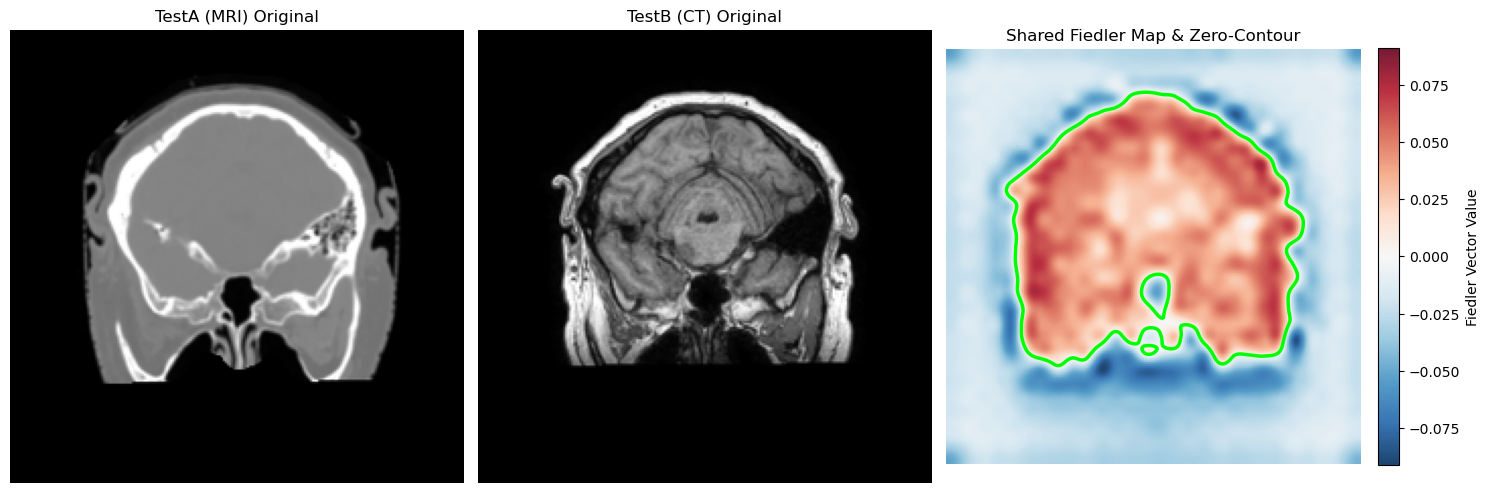

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
from torchvision.models import ViT_B_16_Weights, vit_b_16
import math
from scipy.linalg import eigh
from pathlib import Path

# --- 核心计算类：提取最后一层完整的 N x N 注意力矩阵 ---

class LastBlockRawAttention:
    def __init__(self, model):
        self.model = model
        self.attention = None
        self._register_hooks()

    def _register_hooks(self):
        """挂载 Hook 到最后一个 Transformer Block"""
        self.model.blocks[-1].attn.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        """拦截 (B, Num_Heads, N, N) 的注意力矩阵"""
        if isinstance(output, tuple) and len(output) == 2:
            self.attention = output[1].detach().cpu()
        else:
            raise RuntimeError("Hook 捕获格式不匹配。")

    def __call__(self, input_tensor):
        self.attention = None
        with torch.no_grad():
            self.model(input_tensor)
        
        # 提取 Batch 0，并对所有 Head 求平均，返回形状 (N, N)
        # 这里的 N = grid_size * grid_size + 1 (包含了 CLS token)
        return self.attention[0].mean(dim=0)


# --- 谱图理论与融合数学函数 ---

def extract_shared_structure(attn_mri, attn_ct):
    """
    通过几何平均融合 MRI 和 CT 注意力矩阵，并提取 Fiedler Map
    attn_mri, attn_ct 形状均为 (N, N)
    """
    # 动态计算 grid_size (减去 1 个 CLS token 后开平方)
    grid_size = int(math.sqrt(attn_mri.shape[0] - 1))
    
    # 1. 剔除 CLS Token 并对称化 (构建空间无向图)
    A_mri_patch = attn_mri[1:, 1:].numpy()
    A_ct_patch = attn_ct[1:, 1:].numpy()
    
    A_mri_sym = (A_mri_patch + A_mri_patch.T) / 2.0
    A_ct_sym = (A_ct_patch + A_ct_patch.T) / 2.0
    
    # 2. 几何平均融合: A_shared = sqrt(A_mri * A_ct)
    A_shared = np.sqrt(A_mri_sym * A_ct_sym)
    np.fill_diagonal(A_shared, 0) # 消除自环
    
    # 3. 构建对称归一化拉普拉斯矩阵 L_sym
    degree_vector = np.sum(A_shared, axis=1)
    d_inv_sqrt = np.power(np.maximum(degree_vector, 1e-12), -0.5)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    
    I = np.eye(A_shared.shape[0])
    L_sym = I - np.dot(D_inv_sqrt, np.dot(A_shared, D_inv_sqrt))
    
    # 4. 特征分解提取 Fiedler Vector
    eigenvalues, eigenvectors = eigh(L_sym)
    fiedler_vector = eigenvectors[:, 1] # 第二小特征向量
    
    # 恢复 2D 拓扑形状
    fiedler_map = fiedler_vector.reshape((grid_size, grid_size))
    
    return fiedler_map


# --- 工具函数 ---

def load_and_extract_attention(image_path, model, extractor, image_size=224):
    """读取单张图片，返回原始图和 N x N 注意力矩阵"""
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    img = Image.open(image_path).convert("RGB")
    device = next(model.parameters()).device
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    attn_matrix = extractor(input_tensor)
    img_resized = np.array(img.resize((image_size, image_size)))
    
    return img_resized, attn_matrix


# --- Notebook 运行主逻辑 ---

# 1. 配置参数 (在此修改你的实际路径)
IMG_PATH_A = "/home/ljc/code/PaBoT-main/datasets/testA/1BA278_slice092.png" # MRI
IMG_PATH_B = "/home/ljc/code/PaBoT-main/datasets/testB/1BA278_slice092.png" # CT
IMG_SIZE = 224

# 2. 初始化模型
print("正在加载 DINO 模型 (Patch Size 8)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8').to(device).eval()
extractor = LastBlockRawAttention(model)

# 3. 提取特征
print("正在提取并计算图谱融合特征...")
mri_orig, attn_mri = load_and_extract_attention(IMG_PATH_A, model, extractor, IMG_SIZE)
ct_orig, attn_ct = load_and_extract_attention(IMG_PATH_B, model, extractor, IMG_SIZE)

# 4. 执行图割数学逻辑 (计算共享 Fiedler Map)
fiedler_map = extract_shared_structure(attn_mri, attn_ct)

# 将 Fiedler Map 上采样到原图尺寸以进行可视化
fiedler_map_resized = cv2.resize(fiedler_map, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)

# 5. 可视化绘制 (1行3列: MRI, CT, Fiedler Contour)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 绘制 MRI
axes[0].imshow(mri_orig)
axes[0].set_title("TestA (MRI) Original")
axes[0].axis('off')

# 绘制 CT
axes[1].imshow(ct_orig)
axes[1].set_title("TestB (CT) Original")
axes[1].axis('off')

# 绘制 Fiedler Map 与 Contour
limit = np.max(np.abs(fiedler_map_resized))
im = axes[2].imshow(fiedler_map_resized, cmap='RdBu_r', vmin=-limit, vmax=limit, alpha=0.9)
# 绘制数学图割零点边界
axes[2].contour(fiedler_map_resized, levels=[0.0], colors='lime', linewidths=2.5)
axes[2].set_title(r"Shared Fiedler Map & Zero-Contour")
axes[2].axis('off')

# 添加颜色条
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Fiedler Vector Value')

plt.tight_layout()
plt.show()